# 1.0 Package Import

## 1.1 Package installed (once)

In [6]:
import sys
print(sys.executable)


/Users/tee/Projects/pj1_car/venv/bin/python


In [20]:
!{sys.executable} -m pip install pillow

  Using cached pillow-11.3.0-cp39-cp39-macosx_11_0_arm64.whl.metadata (9.0 kB)
Using cached pillow-11.3.0-cp39-cp39-macosx_11_0_arm64.whl (4.7 MB)


In [22]:
!{sys.executable} -m pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 6.6 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 6.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


In [13]:
!{sys.executable} -m pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 6.7 MB/s  0:00:01m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]


In [22]:
!{sys.executable} -m pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.4/200.4 MB 6.7 MB/s  0:00:30m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 6.6 MB/s  0:00:01m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 5.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 6.6 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 6.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 6.7 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25/25 [tensorflow]5 [tensorflow]]py]


In [7]:
pip install ultralytics

Note: you may need to restart the kernel to use updated packages.


In [27]:
pip install torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 6.4 MB/s  0:00:00 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


## 1.2 Package import (Always)

In [2]:
import pandas as pd
from PIL import Image
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np

In [3]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Is GPU available?", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
Is GPU available? []


In [4]:
import platform, sys
print("Python:", sys.executable)
print("Arch:", platform.machine())

Python: /Users/tee/Projects/pj1_car/venv/bin/python
Arch: arm64


In [5]:

import torch
device = "mps" if torch.backends.mps.is_available() else "cpu"

In [6]:
import shutil
from ultralytics import YOLO

In [7]:
import cv2
import matplotlib.patches as patches
import glob, time, random, os

# 2.0 Data Import

## 2.1 Sample CSV Data Processing

In [8]:
df_sample_csv = pd.read_csv("../data/CompCar/data/misc/sample_total.csv")
print(df_sample_csv.shape)
print(df_sample_csv.head())

(28441, 15)
   make_id  model_id  year      image_name  angle_no  \
0        4       509  2012  f97e46eaed9da4         2   
1        4       509  2012  43f62e8325352e         2   
2        4       509  2012  11689a8ea7b28f         2   
3        4       509  2012  741aea0835b7de         5   
4        4       509  2012  c0efd6d84ae9ba         5   

                      image_path angle_side model_names  maximum_speed  \
0  4/509/2012/f97e46eaed9da4.jpg       rear        DS 5          202.0   
1  4/509/2012/43f62e8325352e.jpg       rear        DS 5          202.0   
2  4/509/2012/11689a8ea7b28f.jpg       rear        DS 5          202.0   
3  4/509/2012/741aea0835b7de.jpg  rear-side        DS 5          202.0   
4  4/509/2012/c0efd6d84ae9ba.jpg  rear-side        DS 5          202.0   

   displacement  door_number  seat_number  type_id   car_type make_names  
0           1.6          5.0          5.0        4  hatchback         DS  
1           1.6          5.0          5.0        4  hatc

In [9]:
# Create a training label
df_sample_csv["tlb_model_yr"] = (df_sample_csv["make_id"].astype(str)+ "_" +df_sample_csv["model_id"].astype(str)+ "_" + df_sample_csv["year"].astype(str))
df_sample_csv[["make_id", "model_id", "year", "model_names", "tlb_model_yr"]].head(10)

,make_id,model_id,year,model_names,tlb_model_yr
0,4,509,2012,DS 5,4_509_2012
1,4,509,2012,DS 5,4_509_2012
2,4,509,2012,DS 5,4_509_2012
3,4,509,2012,DS 5,4_509_2012
4,4,509,2012,DS 5,4_509_2012
5,4,509,2012,DS 5,4_509_2012
6,4,509,2012,DS 5,4_509_2012
7,4,509,2012,DS 5,4_509_2012
8,4,509,2012,DS 5,4_509_2012
9,4,509,2012,DS 5,4_509_2012


In [10]:
df_sample_csv.shape

(28441, 16)

In [11]:
# Filter out for the tlb_model_yr containing less than 8 samples
counts = df_sample_csv["tlb_model_yr"].value_counts()
df_sample_filtered = df_sample_csv[df_sample_csv["tlb_model_yr"].isin(counts[counts > 7].index)]
print(df_sample_filtered["tlb_model_yr"].value_counts().head())
print(df_sample_filtered.shape)

tlb_model_yr
4_509_2012       10
114_1437_2008    10
111_1703_2014    10
111_1703_2015    10
111_1704_2014    10
Name: count, dtype: int64
(26419, 16)


In [12]:
### Around Another 2k samples have been filtered out. 
print(df_sample_filtered.head())

   make_id  model_id  year      image_name  angle_no  \
0        4       509  2012  f97e46eaed9da4         2   
1        4       509  2012  43f62e8325352e         2   
2        4       509  2012  11689a8ea7b28f         2   
3        4       509  2012  741aea0835b7de         5   
4        4       509  2012  c0efd6d84ae9ba         5   

                      image_path angle_side model_names  maximum_speed  \
0  4/509/2012/f97e46eaed9da4.jpg       rear        DS 5          202.0   
1  4/509/2012/43f62e8325352e.jpg       rear        DS 5          202.0   
2  4/509/2012/11689a8ea7b28f.jpg       rear        DS 5          202.0   
3  4/509/2012/741aea0835b7de.jpg  rear-side        DS 5          202.0   
4  4/509/2012/c0efd6d84ae9ba.jpg  rear-side        DS 5          202.0   

   displacement  door_number  seat_number  type_id   car_type make_names  \
0           1.6          5.0          5.0        4  hatchback         DS   
1           1.6          5.0          5.0        4  hatchback     

## 2.2 Sample Image Data Import and Processing

In [13]:
# Load image later in the model training session to save ram
image_root_dir = "../data/CompCar/data/image"

# 3.0 Model Training

## 3.1 Dataset Split

In [14]:
df = df_sample_filtered.copy()

In [15]:
# Manual filter 1 for testing, 1 for validation and remaining 6-8 for training in each group 
# because the current sample data is not big for each group. 
# Later "from sklearn.model_selection import train_test_split" can be use for larger dataset
train_parts, val_parts, test_parts = [], [], []
for label, g in df.groupby("tlb_model_yr", sort=False):
    g = g.sample(frac=1, random_state=42).reset_index(drop=True)
    test = g.iloc[:1]
    val  = g.iloc[1:2]
    train = g.iloc[2:]

    train_parts.append(train)
    val_parts.append(val)
    test_parts.append(test)
df_train = pd.concat(train_parts).reset_index(drop=True)
df_val   = pd.concat(val_parts).reset_index(drop=True)
df_test  = pd.concat(test_parts).reset_index(drop=True)

print(f"Train: {len(df_train)}  |  Val: {len(df_val)}  |  Test: {len(df_test)}")

Train: 21067  |  Val: 2676  |  Test: 2676


In [16]:
print(df_train.shape)
print(df_val.shape)
print(df_test.shape)

(21067, 16)
(2676, 16)
(2676, 16)


In [17]:
# Output Train/val/testing dataset from Sample dataset all 
df_train.to_csv('../data/CompCar/data/misc/sample_train.csv', index=False)
df_val.to_csv('../data/CompCar/data/misc/sample_val.csv', index=False)
df_test.to_csv('../data/CompCar/data/misc/sample_test.csv', index=False)

## 3.2 Create Yolo Structure 

### only need to run once

In [17]:
ROOT = "../data/yolo_sample"
IMG_DIR = os.path.join(ROOT, "images")
LBL_DIR = os.path.join(ROOT, "labels")
os.makedirs(os.path.join(IMG_DIR, "train"), exist_ok=True)
os.makedirs(os.path.join(IMG_DIR, "val"), exist_ok=True)
os.makedirs(os.path.join(IMG_DIR, "test"), exist_ok=True)
os.makedirs(os.path.join(LBL_DIR, "train"), exist_ok=True)
os.makedirs(os.path.join(LBL_DIR, "val"), exist_ok=True)
os.makedirs(os.path.join(LBL_DIR, "test"), exist_ok=True)

In [33]:
# # Copy images from data source
# def copy_split(df_split, split_name):
#     dst_dir = os.path.join(ROOT, "images", split_name)
#     for _, row in df_split.iterrows():
#         src = os.path.join(image_root_dir, row["image_path"])
#         dst = os.path.join(dst_dir, row["image_path"])
#         if not os.path.exists(src):
#             print(f"Missing: {src}")
#             continue
#         os.makedirs(os.path.dirname(dst), exist_ok=True)     # create subfolders
#         shutil.copy2(src, dst)                               # copy with metadata preserved

# copy_split(df_train, "train")
# copy_split(df_val, "val")
# copy_split(df_test, "test")

# print("Done copying splits into YOLO-style folders at:", ROOT)

Done copying splits into YOLO-style folders at: ../data/yolo_sample


In [34]:
# # Use this txt files as back up plan as Yolov8 can't find all cars
# # Copy txt from data source
# txt_root_dir = "../data/CompCar/data/label"

# def copy_split_txt(df_split, split_name):
#     dst_dir = os.path.join(ROOT, "labels", split_name)
#     for _, row in df_split.iterrows():
#         rel_img_path = row["image_path"]
#         rel_lbl_path = os.path.splitext(rel_img_path)[0] + ".txt"
#         src = os.path.join(txt_root_dir, rel_lbl_path)
#         dst = os.path.join(dst_dir, rel_lbl_path)
#         if not os.path.exists(src):
#             print(f"Missing: {src}")
#             continue
#         os.makedirs(os.path.dirname(dst), exist_ok=True)     # create subfolders
#         shutil.copy2(src, dst)                               # copy with metadata preserved

# copy_split_txt(df_train, "train")
# copy_split_txt(df_val, "val")
# copy_split_txt(df_test, "test")

# print("Done copying splits into YOLO-style folders at:", ROOT)


In [18]:
# crop info testing
images_root = "../data/yolo_sample/images"
custom_labels_root = "../data/yolo_sample/labels"
yolo_labels_root  = "../data/yolo_sample/label3"

In [34]:
def parse_custom_label(txt_path):
    with open(txt_path, "r") as f:
        lines = [ln.strip() for ln in f if ln.strip()]
    if len(lines) < 3:
        return None
    parts = lines[-1].split()  # 3rd line has bbox
    if len(parts) != 4:
        return None
    x1, y1, x2, y2 = map(float, parts)
    return x1, y1, x2, y2

def convert_and_save(img_path):
    # find matching txt in label2
    rel = img_path.split("/images/", 1)[-1]                 
    txt_custom = os.path.join(custom_labels_root, os.path.splitext(rel)[0] + ".txt")
    if not os.path.exists(txt_custom):
        return False

    bbox = parse_custom_label(txt_custom)
    if bbox is None:
        return False
    x1, y1, x2, y2 = bbox

    # load image to get size
    img = cv2.imread(img_path)
    if img is None:
        return False
    H, W = img.shape[:2]

    # convert to YOLO format
    w, h = x2 - x1, y2 - y1
    xc, yc = x1 + w/2.0, y1 + h/2.0
    xc_n, yc_n, w_n, h_n = xc/W, yc/H, w/W, h/H

    # output path
    txt_out = os.path.join(yolo_labels_root, os.path.splitext(rel)[0] + ".txt")
    os.makedirs(os.path.dirname(txt_out), exist_ok=True)

    # write YOLO txt (force class 0 = vehicle)
    with open(txt_out, "w") as f:
        f.write(f"0 {xc_n:.6f} {yc_n:.6f} {w_n:.6f} {h_n:.6f}\n")
    return True


In [35]:
splits = ["train", "val"]
converted, total = 0, 0
for split in splits:
    imgs = glob.glob(os.path.join(images_root, split, "**/*.jpg"), recursive=True)
    for img_path in imgs:
        total += 1
        if convert_and_save(img_path):
            converted += 1

print(f"Converted {converted}/{total} images into YOLO txts at: {yolo_labels_root}")

Converted 23743/23743 images into YOLO txts at: ../data/yolo_sample/label3


Found 23743 label files


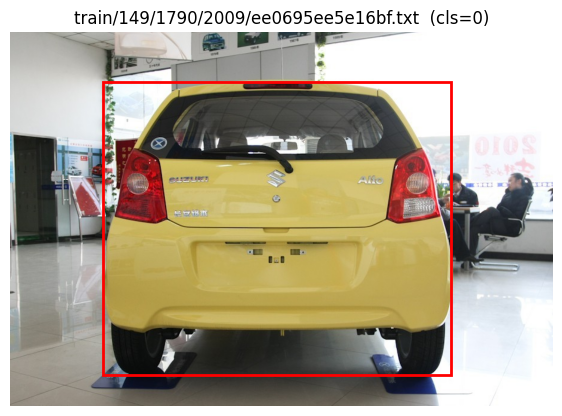

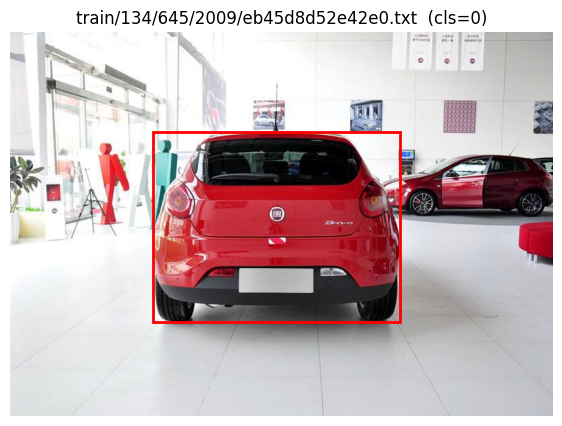

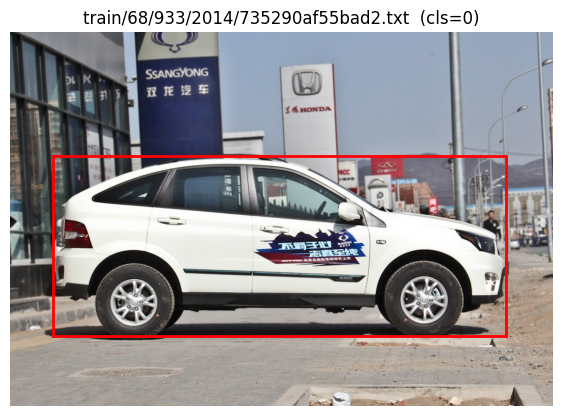

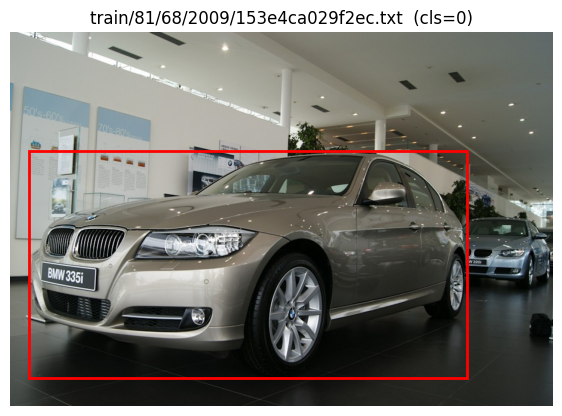

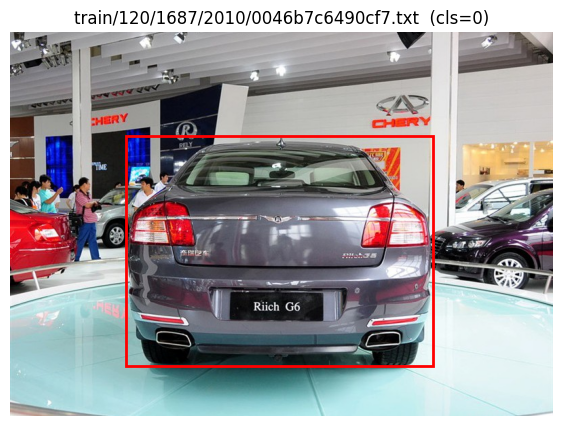

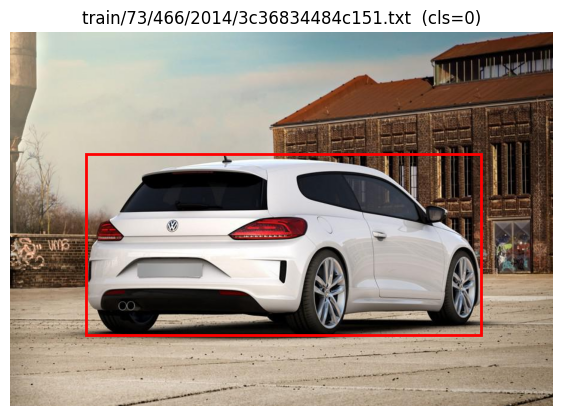

In [36]:
# Checking bbox files
labels_root = "../data/yolo_sample/label3"
images_root = "../data/yolo_sample/images"
K = 6 

# collect all txts
txts = glob.glob(os.path.join(yolo_labels_root, "**", "*.txt"), recursive=True)
print(f"Found {len(txts)} label files")

random.seed(42)
sample = random.sample(txts, min(K, len(txts)))

def read_yolo_line(txt_path):
    with open(txt_path, "r") as f:
        for ln in f:
            ln = ln.strip()
            if not ln:
                continue
            parts = ln.split()
            if len(parts) != 5:
                return None
            cls = int(float(parts[0]))
            xc, yc, w, h = map(float, parts[1:])
            return cls, xc, yc, w, h
    return None

for t in sample:
    rel = t.split("/label3/", 1)[-1]                
    img_path = os.path.join(images_root, os.path.splitext(rel)[0] + ".jpg")

    if not os.path.exists(img_path):
        print(f"Image missing for {rel}")
        continue

    parsed = read_yolo_line(t)
    if parsed is None:
        print(f"No valid YOLO line in {t}")
        continue

    cls, xc, yc, w, h = parsed

    # load image to convert normalized coords → pixels
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print(f"Cannot read {img_path}")
        continue
    H, W = img_bgr.shape[:2]
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # denormalize and get xyxy
    bw, bh = w * W, h * H
    x1 = int((xc * W) - bw / 2)
    y1 = int((yc * H) - bh / 2)
    x2 = int(x1 + bw)
    y2 = int(y1 + bh)

    # clamp to image
    x1 = max(0, min(W - 1, x1)); x2 = max(0, min(W - 1, x2))
    y1 = max(0, min(H - 1, y1)); y2 = max(0, min(H - 1, y2))

    # plot
    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    ax.imshow(img)
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                             linewidth=2, edgecolor="red", facecolor="none")
    ax.add_patch(rect)
    ax.set_title(rel + f"  (cls={cls})")
    ax.axis("off")
    plt.show()

### Model Testing

In [45]:
## Keep only the biggest vehicle crop per image.
## If the biggest detection is too small (< min_area_ratio of image), retry with looser settings.

def save_biggest_crop_cascade(model, paths, out_dir,
                              conf_hi=0.30, conf_lo=0.10,
                              iou=0.50, imgsz_hi=640, imgsz_lo=960,
                              classes=[2,5], max_det=30,
                              min_area_ratio=0.05, padding=0.01, device="mps"):

    os.makedirs(out_dir, exist_ok=True)

    def _predict_once(src, conf, imgsz):
        return model.predict(
            source=src, imgsz=imgsz, device=device,
            conf=conf, iou=iou, classes=classes, max_det=max_det,
            save=False, verbose=False
        )[0]

    for p in paths:
        img_bgr = cv2.imread(p)
        if img_bgr is None:
            continue
        H, W = img_bgr.shape[:2]
        img_area = float(W * H)

        r = _predict_once(p, conf_hi, imgsz_hi)

        def pick_biggest(res):
            if res.boxes is None or len(res.boxes) == 0:
                return None
            xyxy = res.boxes.xyxy.cpu().numpy()
            areas = (xyxy[:,2]-xyxy[:,0]) * (xyxy[:,3]-xyxy[:,1])
            k = int(np.argmax(areas))
            return xyxy[k]

        box = pick_biggest(r)

        # if no box OR box too tiny, try a second
        if box is None or ((box[2]-box[0])*(box[3]-box[1])) / img_area < min_area_ratio:
            r2 = _predict_once(p, conf_lo, imgsz_lo)
            box2 = pick_biggest(r2)
            if box is None or (box2 is not None and
               ((box2[2]-box2[0])*(box2[3]-box2[1])) > ((box[2]-box[0])*(box[3]-box[1]) if box is not None else -1)):
                box = box2

        if box is None:
            # save original if nothing detected
            rel = p.split("/images/", 1)[-1]
            dst = os.path.join(out_dir, rel)
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            cv2.imwrite(dst, img_bgr)
            continue

        x1, y1, x2, y2 = map(int, box)
        w, h = x2 - x1, y2 - y1
        dx, dy = int(padding*w), int(padding*h)
        px1 = max(0, x1 - dx); py1 = max(0, y1 - dy)
        px2 = min(W, x2 + dx); py2 = min(H, y2 + dy)

        crop = img_bgr[py1:py2, px1:px2]
        if crop.size == 0:
            continue
        rel = p.split("/images/", 1)[-1]
        dst = os.path.join(out_dir, rel)
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        cv2.imwrite(dst, crop)


In [46]:
out_dir = "../data/yolo_sample/crops_benchmark/yolov8n_cascade"
save_biggest_crop_cascade(
    model=YOLO("yolov8n.pt"),
    paths=sample,            
    out_dir=out_dir,
    conf_hi=0.30, conf_lo=0.10,
    iou=0.50,
    imgsz_hi=640, imgsz_lo=960,
    classes=[2,5], 
    max_det=100,
    min_area_ratio=0.05,        # require at least 5% of image area
    padding=0.0,
    device="mps"
)

Found 200 cropped images


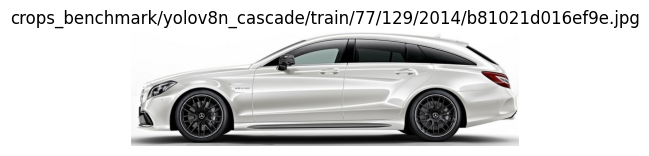

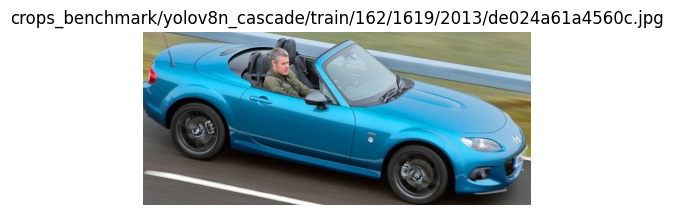

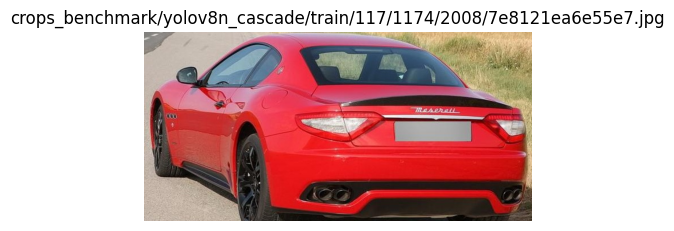

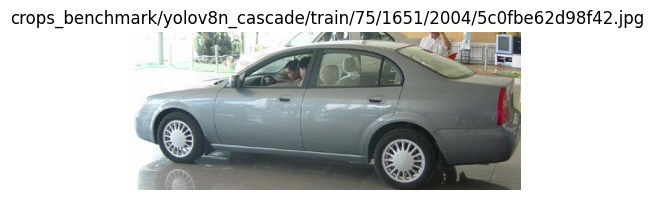

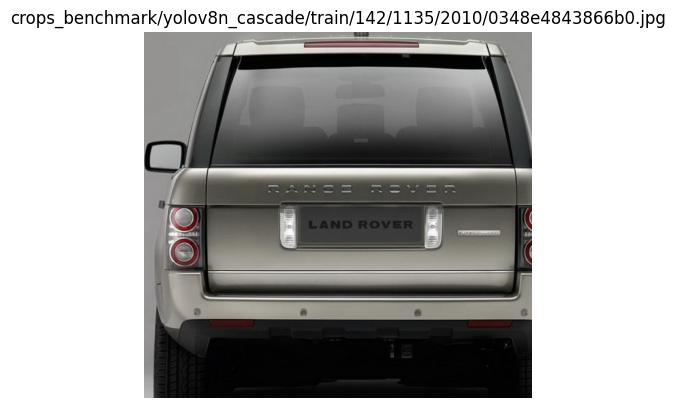

In [47]:
crops = glob.glob(out_dir + "/**/*.jpg", recursive=True)
print(f"Found {len(crops)} cropped images")

# show a few random crops
for p in random.sample(crops, min(5, len(crops))):
    img = cv2.imread(p)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.title(p.split("/yolo_sample/")[-1])
    plt.axis("off")
    plt.show()

Showing: ../data/yolo_sample/crops_benchmark/yolov8n_cascade/train/134/645/2009/8aa2d4a8ebc00a.jpg


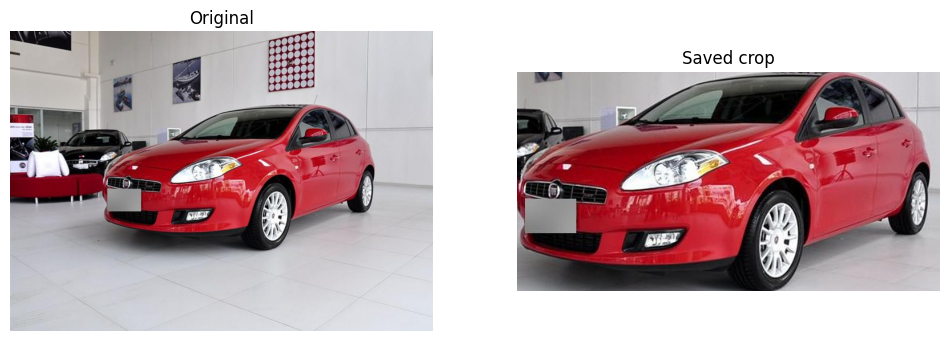

In [48]:
p = random.choice(crops)
print("Showing:", p)

# original image path is the same, but under /images/
orig = p.replace("/crops_benchmark/yolov8n_cascade/", "/images/")
img_orig = cv2.imread(orig)
img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)

img_crop = cv2.imread(p)
img_crop = cv2.cvtColor(img_crop, cv2.COLOR_BGR2RGB)

# display side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))
ax1.imshow(img_orig); ax1.set_title("Original")
ax1.axis("off")
ax2.imshow(img_crop); ax2.set_title("Saved crop")
ax2.axis("off")
plt.show()

In [49]:
def write_yolo_txt_for_biggest_box(
    model, paths,
    conf_hi=0.30, conf_lo=0.10,
    iou=0.50, imgsz_hi=640, imgsz_lo=960,
    classes=[2,5], # 2 as car; 5 as bus
    max_det=30,
    min_area_ratio=0.05, padding=0.01, device="mps",
    label_out_root="../data/yolo_sample/label2",
    class_id_override=0
):
    os.makedirs(label_out_root, exist_ok=True)
    found, total = 0, 0

    def _predict_once(src, conf, imgsz):
        return model.predict(
            source=src, imgsz=imgsz, device=device,
            conf=conf, iou=iou, classes=classes, max_det=max_det,
            save=False, verbose=False
        )[0]

    def pick_biggest(res):
        if res.boxes is None or len(res.boxes) == 0:
            return None
        xyxy = res.boxes.xyxy.cpu().numpy()
        areas = (xyxy[:,2]-xyxy[:,0]) * (xyxy[:,3]-xyxy[:,1])
        return int(np.argmax(areas))

    for p in paths:
        total += 1
        img = cv2.imread(p)
        if img is None:
            continue
        H, W = img.shape[:2]
        img_area = float(W * H)

        r = _predict_once(p, conf_hi, imgsz_hi)
        k = pick_biggest(r)
        box = r.boxes.xyxy.cpu().numpy()[k] if k is not None else None

        # fallback if none or too small
        def area(b): 
            return 0 if b is None else (b[2]-b[0])*(b[3]-b[1])
        if box is None or area(box)/img_area < min_area_ratio:
            r2 = _predict_once(p, conf_lo, imgsz_lo)
            k2 = pick_biggest(r2)
            if k2 is not None:
                box2 = r2.boxes.xyxy.cpu().numpy()[k2]
                if area(box2) > area(box if box is not None else [-1,-1,-1,-1]):
                    box = box2

        # txt path
        rel = p.split("/images/", 1)[-1]
        txt_path = os.path.join(label_out_root, os.path.splitext(rel)[0] + ".txt")
        os.makedirs(os.path.dirname(txt_path), exist_ok=True)

        with open(txt_path, "w") as f:
            if box is None:
                # empty file = no detection
                continue
            found += 1
            x1, y1, x2, y2 = map(int, box)
            bw, bh = x2 - x1, y2 - y1
            dx, dy = int(padding*bw), int(padding*bh)
            px1 = max(0, x1 - dx); py1 = max(0, y1 - dy)
            px2 = min(W, x2 + dx); py2 = min(H, y2 + dy)
            w, h = px2 - px1, py2 - py1
            xc, yc = px1 + w/2.0, py1 + h/2.0
            f.write(f"{class_id_override} {xc/W:.6f} {yc/H:.6f} {w/W:.6f} {h/H:.6f}\n")

    return found, total


In [50]:
# Tested yolov8m.pt, yolov8s.pt and yolov8n.pt with different measurement 
# yolov8s.pt is the slowest and give the worst result. yolov8n.pt is much faster than yolov8m.pt but yolov8m.pt might give slightly better result. 
# Use yolov8n.pt for now. Consider if it's need to be changed to yolov8m.pt later. 
model = YOLO("yolov8n.pt")
train_imgs = glob.glob("../data/yolo_sample/images/train/**/*.jpg", recursive=True)
val_imgs   = glob.glob("../data/yolo_sample/images/val/**/*.jpg", recursive=True)

found_train, total_train = write_yolo_txt_for_biggest_box(model, train_imgs)
found_val,   total_val   = write_yolo_txt_for_biggest_box(model, val_imgs)

print(f"Train: {found_train}/{total_train} images had detections")
print(f"Val:   {found_val}/{total_val} images had detections")

Train: 20306/21067 images had detections
Val:   2589/2676 images had detections
